In [ ]:
# Install Libraries
!pip install -q langchain langchain-huggingface transformers torch matplotlib

In [ ]:
# Imports
from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
import matplotlib.pyplot as plt
import time

In [ ]:
# Load Local Model
pipe = pipeline(
    "text-generation",
    model="distilgpt2",
    max_new_tokens=40,
    do_sample=True,
    temperature=0.7,
    repetition_penalty=1.5
)

llm = HuggingFacePipeline(pipeline=pipe)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'do_sample', 'repetition_penalty', 'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [ ]:
# Prompt Template
prompt = PromptTemplate.from_template(
    "Complete the sentence:\n{topic}"
)

In [ ]:
# Create Chain (NEW STYLE)
chain = prompt | llm

In [ ]:
# Topics
topics = [
    "Time management is important because",
    "A healthy lifestyle helps us to",
    "Good communication allows people to",
    "Stress can affect our life by",
    "Habits are formed when we"
]

In [ ]:
# Run Model
times = []

for i, topic in enumerate(topics):
    start = time.time()

    response = chain.invoke({"topic": topic})

    end = time.time()

    times.append(end - start)

    print(f"\nTopic {i+1}: {topic}")
    print(f"Response: {response.strip()}")


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Topic 1: Time management is important because
Response: Complete the sentence:
Time management is important because it gives clarity to what you are doing and how much work. It allows for more consistency between tasks, which makes your life easier when working with others in a less-timely way than having them


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Topic 2: A healthy lifestyle helps us to
Response: Complete the sentence:
A healthy lifestyle helps us to maintain our health. Our body is in a state of self-control and it's important that we don't take advantage or interfere with some other aspect, such as exercise habits (such "training,"


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Topic 3: Good communication allows people to
Response: Complete the sentence:
Good communication allows people to express themselves, but they also don't.


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Topic 4: Stress can affect our life by
Response: Complete the sentence:
Stress can affect our life by simply leaving a note.

Topic 5: Habits are formed when we
Response: Complete the sentence:
Habits are formed when we take in a word and hold them. The concept is, therefore, that there should be no more than one thing or two right now to do--even if it's just another expression of our human


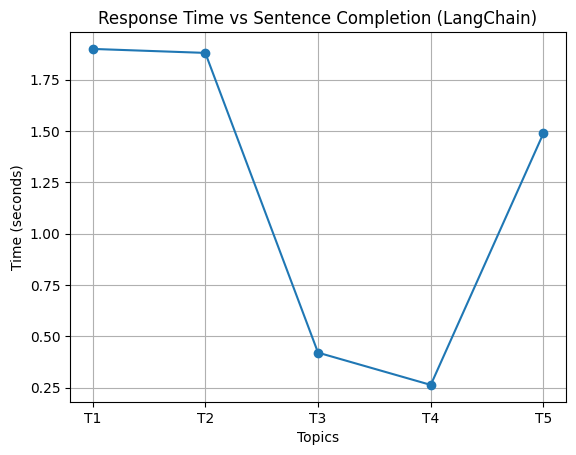

In [ ]:
# Graph
plt.figure()

plt.plot(range(1, len(times)+1), times, marker='o')

plt.title("Response Time vs Sentence Completion (LangChain)")
plt.xlabel("Topics")
plt.ylabel("Time (seconds)")

plt.xticks(range(1, len(topics)+1), ["T1","T2","T3","T4","T5"])

plt.grid(True)
plt.show()